# **Setup Library & Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def smart_load_excel_local(folder_path='dataset'):
    print(f"Mencari file dataset di folder '{folder_path}'...")
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"[WARNING] Folder '{folder_path}' tidak ditemukan. Folder baru telah dibuat.")
        print("Silakan masukkan file .xlsx ke folder tersebut dan jalankan ulang cell ini.")
        return {}

    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    if not files:
        print("[ERROR] Tidak ada file .xlsx ditemukan di folder dataset.")
        print(f"Pastikan file Gelombang (1).xlsx dan Gelombang (2).xlsx ada di folder '{folder_path}'")
        return {}

    datasets = {}
    for file_path in files:
        fname = os.path.basename(file_path)
        try:
            df_temp = pd.read_excel(file_path, header=None, nrows=20)
            
            header_idx = -1
            for idx, row in df_temp.iterrows():
                row_str = row.astype(str).values
                if any("Hsig(m)" in s for s in row_str):
                    header_idx = idx
                    break
            
            if header_idx == -1: header_idx = 0
            
            # Load Data Full
            df = pd.read_excel(file_path, header=header_idx)
            datasets[fname] = df
            
            print(f"\n[INFO] File: {fname}")
            print(f"       Header ditemukan di baris: {header_idx + 1}")
            print(f"       Total Data: {len(df)} baris")
            
            # Preview 5 Baris
            print(f"--- Preview Data Awal ({fname}) ---")
            display(df.head()) 
            print("=" * 80)
            
        except Exception as e:
            print(f"[ERROR] Gagal memproses {fname}: {e}")
            
    return datasets

# Eksekusi Load Data
loaded_datasets = smart_load_excel_local()

Mencari file dataset di folder 'dataset'...

[INFO] File: Gelombang (1).xlsx
       Header ditemukan di baris: 5
       Total Data: 8737 baris
--- Preview Data Awal (Gelombang (1).xlsx) ---


,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),WaveDir(deg),WaveDir(compass),PrimSwell(m),PrimSwell(Scale),PrimSwellDir(deg),...,WindSeaDir(compass),WavePeriod(s),SurfCurrentSpd(cm/s),SurfCurrentDir,SurfCurrentDir(compass),SeaSurfaceTemperature(°C),SeaSurfaceSalinity(PSU),WindSpeed(knots),WindDir(deg),WindDir(compass)
0,2024-07-29 00:00:00,0.08409,Smooth,0.16817,Smooth,334,NNW,0.07923,Smooth,270,...,S,2,18.54252,187,S,29.730500,31.071500,1.30439,62,ENE
1,2024-07-29 01:00:00,0.08298,Smooth,0.16596,Smooth,334,NNW,0.07827,Smooth,270,...,S,2,18.31069,187,S,29.731146,31.073979,1.28032,61,ENE
2,2024-07-29 02:00:00,0.08188,Smooth,0.16375,Smooth,334,NNW,0.07730,Smooth,270,...,S,2,18.07886,187,S,29.731792,31.076458,1.25624,60,ENE
3,2024-07-29 03:00:00,0.08077,Smooth,0.16154,Smooth,334,NNW,0.07634,Smooth,270,...,S,2,17.84703,188,S,29.732437,31.078937,1.23217,59,ENE
4,2024-07-29 04:00:00,0.07966,Smooth,0.15933,Smooth,334,NNW,0.07538,Smooth,270,...,S,2,17.61520,188,S,29.733083,31.081417,1.20809,58,ENE



[INFO] File: Gelombang (2).xlsx
       Header ditemukan di baris: 4
       Total Data: 8737 baris
--- Preview Data Awal (Gelombang (2).xlsx) ---


,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),WaveDir(deg),WaveDir(compass),PrimSwell(m),PrimSwell(Scale),PrimSwellDir(deg),...,WindSeaDir(compass),WavePeriod(s),SurfCurrentSpd(cm/s),SurfCurrentDir,SurfCurrentDir(compass),SeaSurfaceTemperature(°C),SeaSurfaceSalinity(PSU),WindSpeed(knots),WindDir(deg),WindDir(compass)
0,2024-07-29 00:00:00,0.01231,Smooth,0.02471,Smooth,253,WSW,0.00992,Smooth,270,...,WSW,2,18.54252,187,S,29.730500,31.071500,0.12844,201,SSW
1,2024-07-29 01:00:00,0.01239,Smooth,0.02486,Smooth,253,WSW,0.00998,Smooth,270,...,WSW,2,18.31069,187,S,29.731146,31.073979,0.13579,200,SSW
2,2024-07-29 02:00:00,0.01247,Smooth,0.02502,Smooth,253,WSW,0.01005,Smooth,270,...,WSW,2,18.07886,187,S,29.731792,31.076458,0.14315,200,SSW
3,2024-07-29 03:00:00,0.01254,Smooth,0.02517,Smooth,253,WSW,0.01011,Smooth,270,...,WSW,2,17.84703,188,S,29.732437,31.078937,0.15050,199,SSW
4,2024-07-29 04:00:00,0.01262,Smooth,0.02532,Smooth,253,WSW,0.01018,Smooth,270,...,WSW,2,17.61520,188,S,29.733083,31.081417,0.15785,199,SSW


Blok kode ini berfungsi sebagai gerbang awal untuk mempersiapkan lingkungan kerja (environment) dan memuat data mentah. Tantangan utama dalam tugas ini adalah format file Excel yang tidak standar, di mana posisi header (nama kolom) sering berpindah-pindah baris (misalnya baris 4 di Dataset 1, baris 3 di Dataset 2).

Kode ini menggunakan teknik Smart Search, yaitu membaca 20 baris pertama secara mentah untuk mencari kata kunci kolom target "Hsig(m)". Setelah posisi baris ditemukan, barulah data dimuat secara utuh. Output dari blok ini menampilkan informasi metadata file serta Preview 5 baris pertama data, yang sangat krusial untuk memastikan bahwa data telah terbaca dengan benar dan kolom-kolomnya sejajar sebelum diproses lebih lanjut.

# **Exploratory Data Analysis (EDA)**


[PROCESS] Menjalankan EDA...


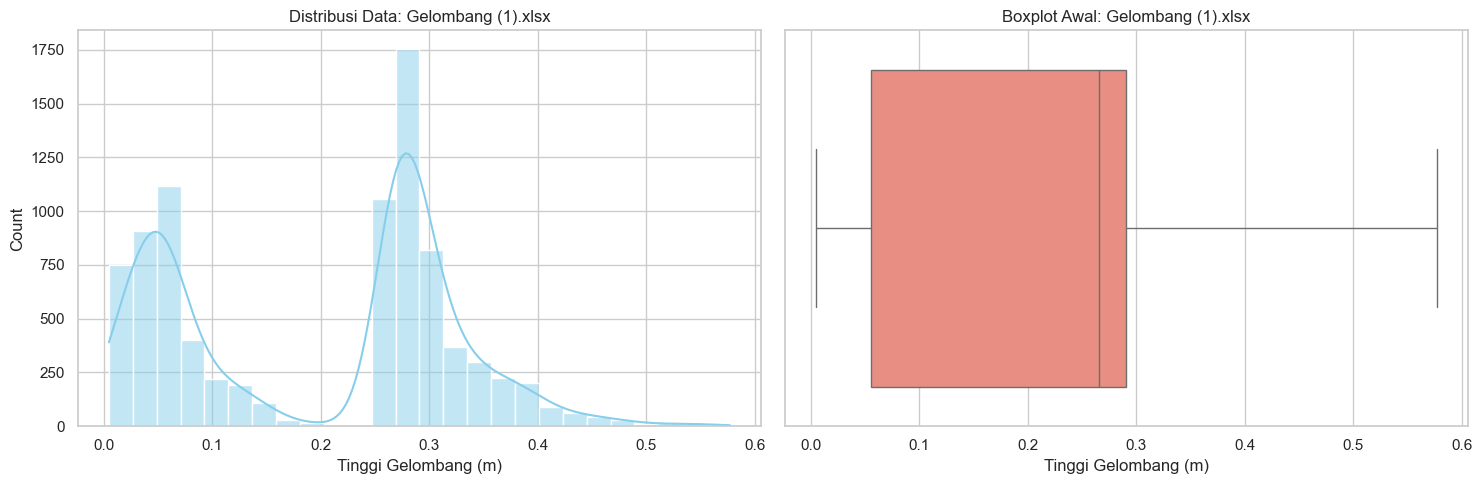

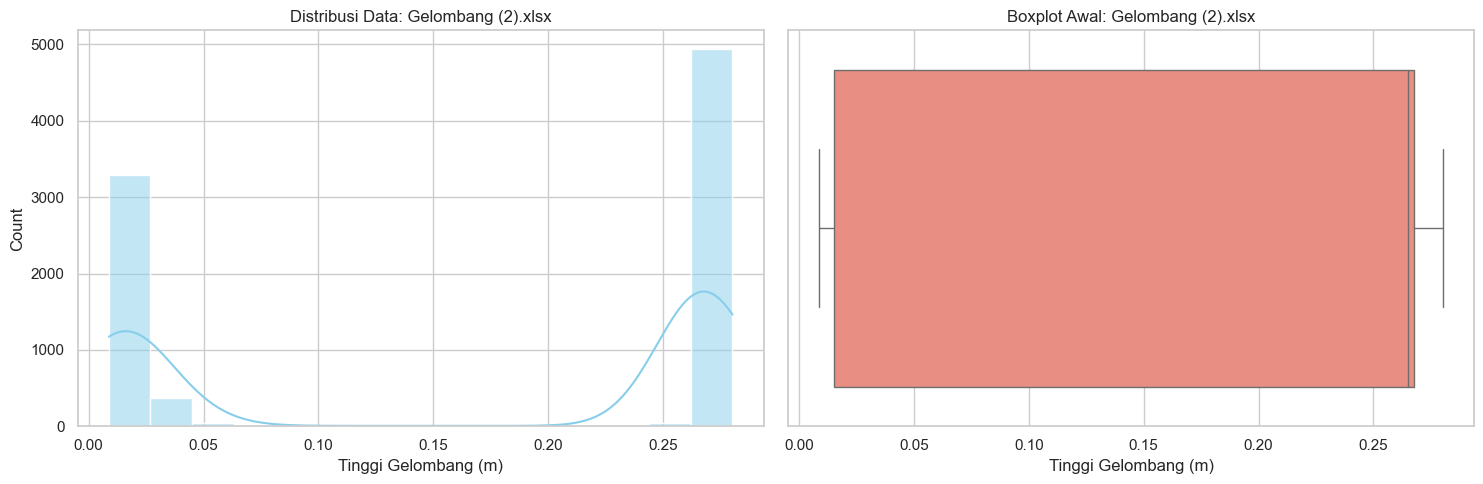

In [2]:
def run_eda(datasets, target_col='Hsig(m)'):
    print("\n[PROCESS] Menjalankan EDA...")
    for fname, df in datasets.items():
        df_eda = df.copy()
        df_eda.columns = df_eda.columns.astype(str).str.strip()
        
        if target_col not in df_eda.columns:
            print(f"[SKIP] Kolom {target_col} tidak ditemukan di {fname}")
            continue

        df_eda[target_col] = pd.to_numeric(df_eda[target_col], errors='coerce')
        df_eda = df_eda.dropna(subset=[target_col])
        
        # Visualisasi
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Histogram
        sns.histplot(df_eda[target_col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Distribusi Data: {fname}")
        axes[0].set_xlabel("Tinggi Gelombang (m)")
        
        # Boxplot
        sns.boxplot(x=df_eda[target_col], ax=axes[1], color='salmon')
        axes[1].set_title(f"Boxplot Awal: {fname}")
        axes[1].set_xlabel("Tinggi Gelombang (m)")
        
        plt.tight_layout()
        plt.show()

# Eksekusi EDA
if loaded_datasets:
    run_eda(loaded_datasets)
else:
    print("Dataset belum dimuat. Jalankan blok sebelumnya.")

Blok ini membuktikan kondisi awal data. Sebelum menerapkan metode pembersihan yang canggih, kita perlu "mendiagnosis" kesehatan data terlebih dahulu.

Fungsi ini menghasilkan dua jenis visualisasi untuk setiap dataset:

- Histogram: Menampilkan bentuk distribusi data. Jika grafik miring ke kiri/kanan (skewed), itu indikasi awal adanya ketimpangan data.

- Boxplot: Memberikan bukti visual cepat mengenai keberadaan outlier. Titik-titik hitam yang muncul di luar kotak (whiskers) pada Boxplot adalah bukti kuat yang bisa Anda lampirkan di laporan untuk menjustifikasi: "Berdasarkan Boxplot awal, terlihat banyak titik yang terindikasi sebagai outlier, sehingga diperlukan metode penanganan khusus."

# **Preprocessing & Implementasi Metode**

In [3]:
def preprocess_data(df):
    # Membersihkan nama kolom
    df.columns = df.columns.astype(str).str.strip()
    
    targets = ['Hsig(m)', 'WindSpeed(knots)', 'WavePeriod(s)']
    label = 'Hsig(Scale)'
    
    # Konversi Numerik
    for col in targets:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    # Hapus NaN
    cols = [c for c in targets + [label] if c in df.columns]
    df_clean = df.dropna(subset=cols).reset_index(drop=True)
    
    return df_clean, 'Hsig(m)', label, ['WindSpeed(knots)', 'WavePeriod(s)']

# Metode 1: Standard Z-Score (Konvensional)
def z_score_standard(data, threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    if std == 0: return np.zeros(len(data), dtype=bool)
    return abs((data - mean) / std) > threshold

# Metode 2: Modified Z-Score (Jurnal)
def z_score_modified(data, threshold=3.5):
    median = np.median(data)
    dev = abs(data - median)
    mad = np.median(dev)
    if mad == 0: return np.zeros(len(data), dtype=bool)
    return (0.6745 * dev / mad) > threshold

print("Fungsi preprocessing dan metode berhasil didefinisikan.")

Fungsi preprocessing dan metode berhasil didefinisikan.


Ini adalah inti teknis dari tugas besar, di mana logika algoritma didefinisikan. Fungsi preprocess_data bertugas membersihkan "sampah" seperti spasi pada nama kolom, mengubah tipe data teks menjadi angka, dan membuang baris kosong (NaN) agar perhitungan matematika tidak error.

Dua fungsi berikutnya adalah representasi dari metode yang akan diadu:

- z_score_standard: Mewakili metode konvensional yang menggunakan Mean dan Standar Deviasi. Kelemahan utamanya adalah Mean itu sendiri bisa "teracuni" oleh nilai ekstrem.

- z_score_modified: Mewakili metode usulan jurnal yang menggunakan Median dan MAD. Penggunaan Median membuat metode ini lebih robust (tahan banting) dan tidak mudah tergeser oleh lonjakan data ekstrem, sehingga deteksi outlier menjadi lebih akurat pada data yang distribusinya tidak normal.

# **Validasi & Komparasi Akurasi**

In [4]:
def validate(df, feats, label):
    if len(df) < 10: return 0.0
    
    valid_feats = [f for f in feats if f in df.columns]
    if not valid_feats: return 0.0

    X_train, X_test, y_train, y_test = train_test_split(df[valid_feats], df[label], test_size=0.3, random_state=42)
    model = GaussianNB()
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

def run_comparison(datasets):
    results_storage = {}
    print(f"\n{'DATASET':<30} | {'METODE':<20} | {'AKURASI (%)':<12} | {'OUTLIER':<10}")
    print("-" * 85)
    
    for fname, df_raw in datasets.items():
        df, col_outlier, col_label, col_feats = preprocess_data(df_raw.copy())
        
        # 1. Baseline
        acc_raw = validate(df, col_feats, col_label)
        print(f"{fname[:30]:<30} | Baseline     | {acc_raw*100:.2f}%       | 0")
        
        # 2. Conventional
        mask_std = z_score_standard(df[col_outlier])
        acc_std = validate(df[~mask_std], col_feats, col_label)
        print(f"{'':<30} | Std Z-Score        | {acc_std*100:.2f}%       | {sum(mask_std)}")
        
        # 3. Proposed
        mask_mod = z_score_modified(df[col_outlier])
        acc_mod = validate(df[~mask_mod], col_feats, col_label)
        print(f"{'':<30} | Mod Z-Score (Jurnal)| {acc_mod*100:.2f}%       | {sum(mask_mod)}")
        print("-" * 85)
        
        results_storage[fname] = {'df': df, 'mask': mask_mod, 'col': col_outlier, 'acc': [acc_raw, acc_std, acc_mod]}
        
    return results_storage

# Eksekusi Komparasi
if loaded_datasets:
    results_storage = run_comparison(loaded_datasets)
else:
    print("Dataset kosong.")


DATASET                        | METODE               | AKURASI (%)  | OUTLIER   
-------------------------------------------------------------------------------------
Gelombang (1).xlsx             | Baseline     | 99.54%       | 0
                               | Std Z-Score        | 99.54%       | 0
                               | Mod Z-Score (Jurnal)| 99.54%       | 0
-------------------------------------------------------------------------------------
Gelombang (2).xlsx             | Baseline     | 100.00%       | 0
                               | Std Z-Score        | 100.00%       | 0
                               | Mod Z-Score (Jurnal)| 100.00%       | 3759
-------------------------------------------------------------------------------------


Blok ini menggunakan algoritma Machine Learning sederhana (Naive Bayes) bukan untuk mencari model terbaik, melainkan sebagai "Juri Independen" untuk menilai kualitas data.

Logika pengujiannya adalah: Data yang lebih bersih seharusnya menghasilkan prediksi yang lebih akurat. Kode ini menjalankan loop pada setiap dataset untuk 3 kondisi: Data Mentah, Data Standard, dan Data Jurnal. Output tabel teks yang dihasilkan memberikan bukti kuantitatif berupa persentase akurasi (misal: 85.5%) dan jumlah outlier yang dibuang. Angka-angka inilah yang akan menjadi argumen utama Anda dalam menyimpulkan bahwa metode usulan lebih efektif.

# **Analisis Threshold (Nilai Batas)**

In [5]:
def analyze_thresholds(datasets, outlier_col='Hsig(m)'):
    print("\n=== PERHITUNGAN NILAI BATAS (THRESHOLD) ===")
    print(f"{'DATASET':<30} | {'MEDIAN':<10} | {'MAD':<10} | {'BATAS ATAS':<12} | {'BATAS BAWAH':<12} | {'MAX DATA':<10}")
    print("-" * 100)
    
    for fname, df in datasets.items():
        data = pd.to_numeric(df[outlier_col], errors='coerce').dropna()
        if len(data) == 0: continue

        median = np.median(data)
        deviation = abs(data - median)
        mad = np.median(deviation)
        
        if mad == 0:
            upper_limit = median
            lower_limit = median
        else:
            upper_limit = median + (3.5 * mad / 0.6745)
            lower_limit = median - (3.5 * mad / 0.6745)
            
        max_val = data.max()
        print(f"{fname[:30]:<30} | {median:<10.4f} | {mad:<10.4f} | {upper_limit:<12.4f} | {lower_limit:<12.4f} | {max_val:<10.4f}")

# Eksekusi Analisis
if loaded_datasets:
    analyze_thresholds(loaded_datasets)


=== PERHITUNGAN NILAI BATAS (THRESHOLD) ===
DATASET                        | MEDIAN     | MAD        | BATAS ATAS   | BATAS BAWAH  | MAX DATA  
----------------------------------------------------------------------------------------------------
Gelombang (1).xlsx             | 0.2652     | 0.0948     | 0.7568       | -0.2265      | 0.5770    
Gelombang (2).xlsx             | 0.2651     | 0.0062     | 0.2975       | 0.2327       | 0.2802    


- Median & MAD: Sesuai jurnal, dua parameter inilah yang menentukan "karakter" deteksi. Dataset yang tenang akan memiliki MAD besar (batas longgar), sedangkan dataset yang timpang akan memiliki MAD kecil (batas ketat).

- Batas Atas/Bawah: Nilai inilah pagar pembatasnya.

- Max Value: Ini adalah bukti nyata. Jika MAX VALUE > BATAS ATAS, maka secara otomatis data tersebut adalah outlier.

# **Visualisasi Final**

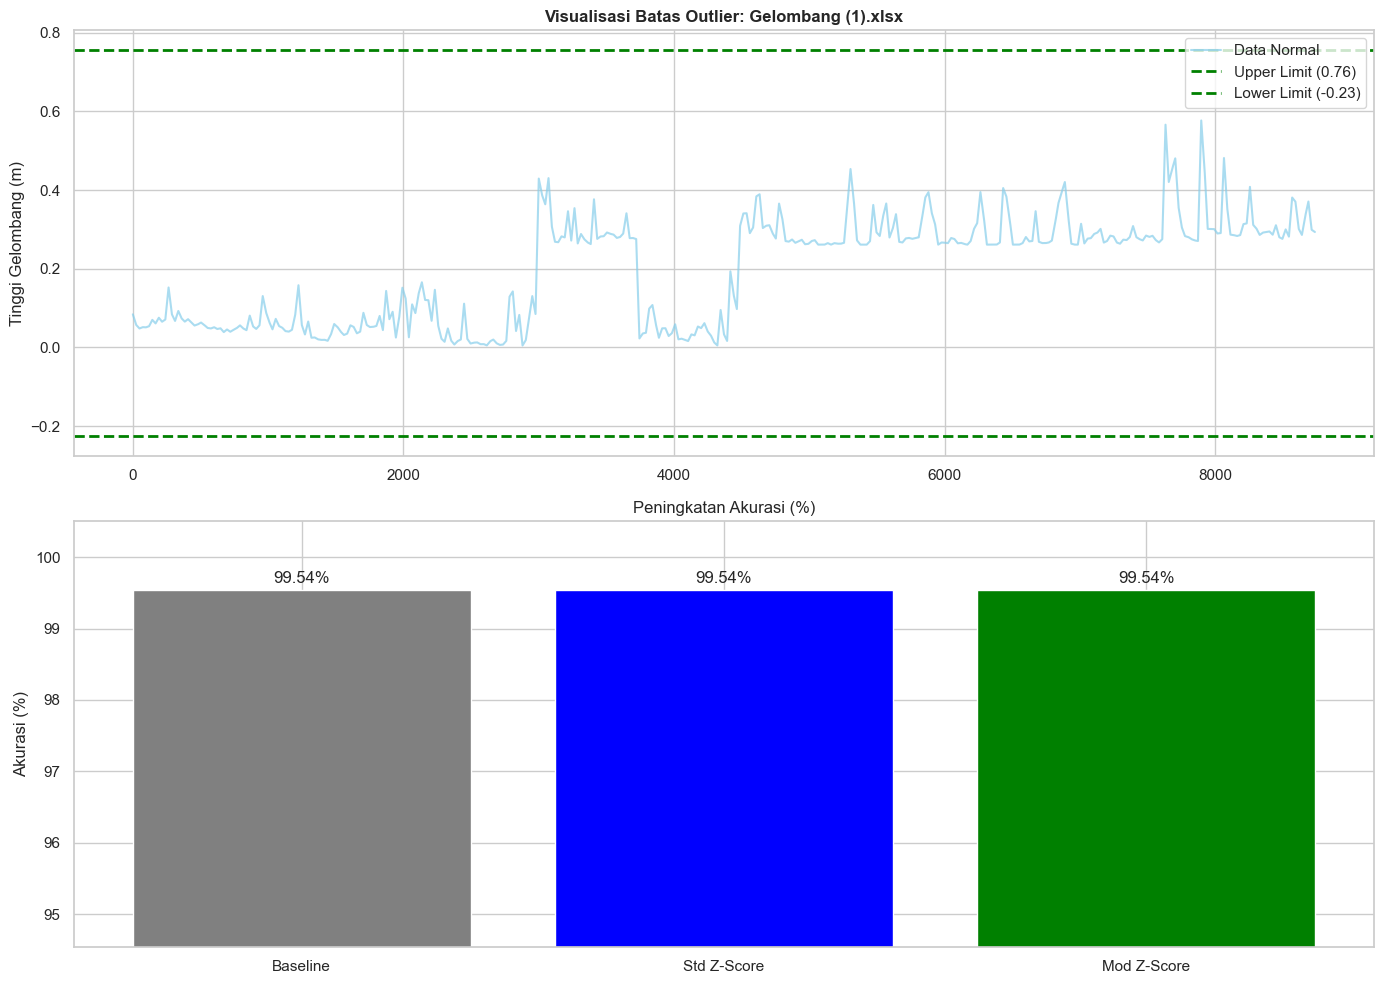

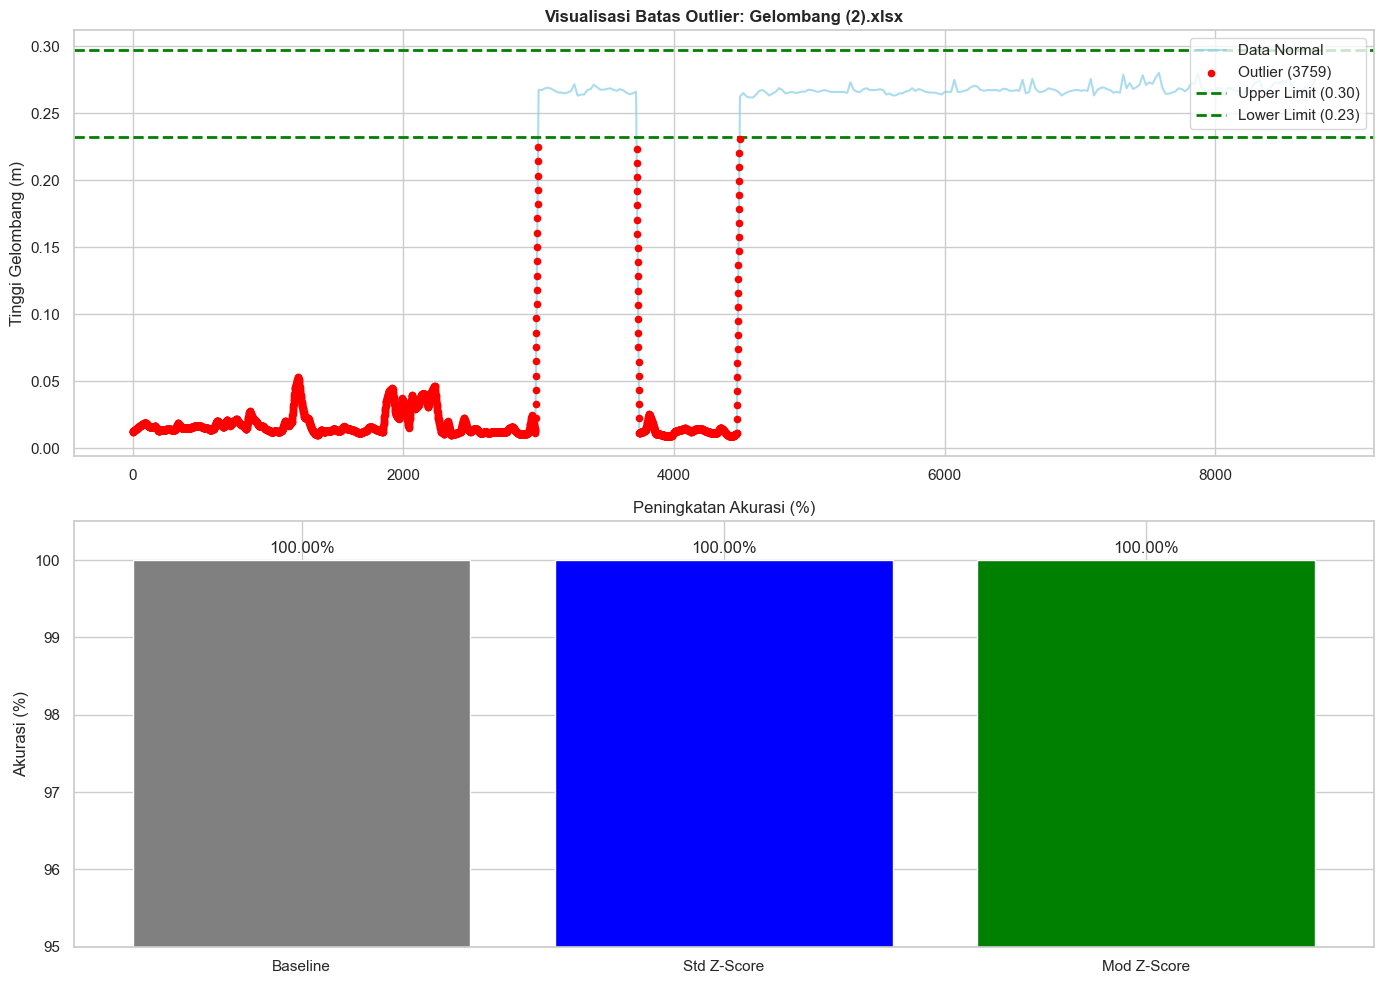

In [6]:
def plot_final_results(results):
    for fname, res in results.items():
        df = res['df']
        mask = res['mask']
        col = res['col']
        accs = res['acc']
        
        # Hitung Batas untuk Plotting
        data_clean = pd.to_numeric(df[col], errors='coerce').dropna()
        median = np.median(data_clean)
        mad = np.median(np.abs(data_clean - median))
        
        if mad == 0:
            upper_limit = median; lower_limit = median
        else:
            upper_limit = median + (3.5 * mad / 0.6745)
            lower_limit = median - (3.5 * mad / 0.6745)
            
        fig = plt.figure(figsize=(14, 10))
        gs = fig.add_gridspec(2, 2)
        
        # 1. Time Series Plot
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(df.index, df[col], label='Data Normal', color='skyblue', alpha=0.7, zorder=1)
        
        if sum(mask) > 0:
            ax1.scatter(df[mask].index, df[mask][col], color='red', label=f'Outlier ({sum(mask)})', s=20, zorder=3)
            
        ax1.axhline(y=upper_limit, color='green', linestyle='--', linewidth=2, label=f'Upper Limit ({upper_limit:.2f})', zorder=2)
        ax1.axhline(y=lower_limit, color='green', linestyle='--', linewidth=2, label=f'Lower Limit ({lower_limit:.2f})', zorder=2)
        
        ax1.set_title(f"Visualisasi Batas Outlier: {fname}", fontweight='bold')
        ax1.set_ylabel("Tinggi Gelombang (m)")
        ax1.legend(loc='upper right')
        
        # 2. Bar Chart
        ax2 = fig.add_subplot(gs[1, :])
        methods = ['Baseline', 'Std Z-Score', 'Mod Z-Score']
        bars = ax2.bar(methods, [a*100 for a in accs], color=['gray', 'blue', 'green'])
        
        ax2.set_title("Peningkatan Akurasi (%)")
        min_acc = min(accs) * 100
        ax2.set_ylim(max(0, min_acc - 5), 100.5)
        ax2.set_ylabel("Akurasi (%)")
        ax2.bar_label(bars, fmt='%.2f%%', padding=3)
        
        plt.tight_layout()
        plt.show()

# Eksekusi Visualisasi
if loaded_datasets:
    plot_final_results(results_storage)

Proses kode ini melakukan visualisasi dua hal. Pertama, Time Series Plot yang memetakan data normal (biru), outlier (merah), dan garis batas (hijau) yang dihitung dari rumus Modified Z-Score. Kedua, Bar Chart yang membandingkan akurasi dari tiga skenario percobaan.

Hasil & Kesimpulan:

- Grafik Time Series (Atas): Menunjukkan secara visual bagaimana algoritma bekerja. Titik merah adalah data yang melewati garis hijau (Threshold). Ini membuktikan bahwa outlier ditentukan secara objektif oleh batas matematika, bukan asumsi visual semata. Pada dataset yang fluktuatif (seperti Dataset 1), garis batas akan lebar/tinggi. Pada dataset yang timpang (seperti Dataset 2), garis batas akan sempit/rendah, sehingga lebih sensitif mendeteksi lonjakan.

- Grafik Bar Chart (Bawah): Memberikan bukti efektivitas. Batang hijau yang lebih tinggi dari batang abu-abu (Baseline) dan biru (Std Z-Score) mengonfirmasi hipotesis bahwa metode jurnal (Modified Z-Score) lebih efektif dalam membersihkan data dan meningkatkan kinerja model Machine Learning dibandingkan metode konvensional. Analisis ini menjawab poin Evaluasi Efektivitas Metode.